# Spot the bug

This notebook mirrors your `notebooks/london/02-04` pipeline, using the
same `src/` helpers and real project data. **Four code cells below
contain a deliberate bug.** The markdown note above each one still
describes what the cell is *supposed* to do — run the cell, compare
what actually happens to what the markdown claims, work out why they
don't match, and fix the code before moving on.

Cells build on each other in order, like a real notebook — if you don't
fix a bug, later cells will inherit the wrong data. That's intentional.

See `README.md` in this folder before you start.

In [8]:
import sys
sys.path.append("../../src")

import pandas as pd
import matplotlib.pyplot as plt

from load_data import load_force_data, load_borough_population, load_borough_deprivation
from clean import clean_crime_data, add_borough_column, LONDON_BOROUGHS

london = load_force_data("london")
london = clean_crime_data(london)
london = add_borough_column(london)

london.shape

(1235489, 9)

## Checking repeated Crime IDs

As in `01_explore.ipynb`, some Crime IDs appear more than once. We want
to see **both** rows of every repeated Crime ID, not just the
second occurrence — so we exclude blank IDs first, then flag every row
that shares a repeated ID.

In [9]:
has_id = london["Crime ID"].notna()
is_repeated = london["Crime ID"].duplicated()

repeated = london[has_id & is_repeated]
repeated.shape[0]

6899

## Per-capita crime rate by borough

Aggregate crime counts by borough and join with ONS population data,
restricted to the 33 real London boroughs (we already know raw
`Borough` values include stray entries from LSOAs outside Greater
London).

In [11]:
borough_counts = london.groupby("Borough").size().reset_index(name="Crime_count")
print(f"{borough_counts.shape[0]} boroughs found")

pop = load_borough_population()
percapita = borough_counts.merge(pop, on="Borough", how="left")
percapita["Rate_per_1000"] = percapita["Crime_count"] / percapita["Population"] * 1000

percapita.sort_values("Rate_per_1000", ascending=False).head(33)

325 boroughs found


,Borough,Crime_count,Population,Rate_per_1000
309,Westminster,97632,209996.0,464.923141
46,Camden,51502,216943.0,237.398764
142,Islington,44201,223024.0,198.189433
143,Kensington and Chelsea,28459,144518.0,196.923567
255,Southwark,52843,314786.0,167.869600
149,Lambeth,52128,316920.0,164.483150
116,Hackney,43333,266758.0,162.443113
287,Tower Hamlets,52375,331886.0,157.810212
63,City of London,2321,15111.0,153.596718
119,Hammersmith and Fulham,28878,188687.0,153.047110


## Correlation with deprivation

As established in `04_deprivation.ipynb`, Westminster and City of London
are footfall/population outliers that distort the per-capita rate — we
exclude them before checking whether deprivation (IMD score) correlates
with per-capita crime rate across the remaining boroughs.

In [27]:
dep = load_borough_deprivation()
merged = percapita.merge(dep, on="Borough")
outliers_borough = merged[merged["Borough"] != "Westminster"]
outliers_borough = outliers_borough[outliers_borough["Borough"] != "City of London"]

correlation = outliers_borough["IMD_score"].corr(outliers_borough["Rate_per_1000"])
print(f"IMD vs per-capita rate correlation (Westminster & City of London excluded): {correlation:.2f}")

IMD vs per-capita rate correlation (Westminster & City of London excluded): 0.57


## Chart — top 10 boroughs by per-capita crime rate

A horizontal bar chart, highest-rate borough at the top.

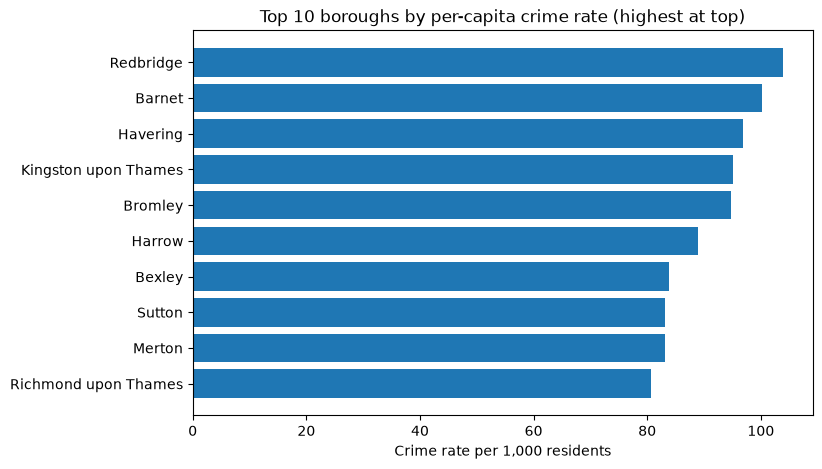

In [31]:
top10 = percapita.sort_values("Rate_per_1000", ascending=True).head(10)

plt.figure(figsize=(8, 5))
plt.barh(top10["Borough"], top10["Rate_per_1000"])
plt.xlabel("Crime rate per 1,000 residents")
plt.title("Top 10 boroughs by per-capita crime rate (highest at top)")
plt.show()